# Weekly Project 05 - 3D Point Cloud Processing 1

## Implementation of global registration

### Task 1

Today, your task is to implement a global registration algorithm.

It should be able to roughly align two point clouds.
Implement the global registration algorithm, and then try the following:

1. Can you fit `r1.pcd` and `r2.pcd`?
2. Can you fit `car1.ply` and `car2.ply`?

The corresponding files are in the `data/global_registration` folder.

### Task 2 (Challenge)

Attempt either or both challenges:

- Implement local registration.

- Attempt to reconstruct the car from the images in the `data/car_challange` folder.

You can use the notebooks from Monday as a starting point.

## Weekly Project 05 - Start Here

In [1]:
import open3d as o3d
import numpy as np
import copy
from pathlib import Path

DATA_DIR = Path("data")

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
# Helper function for drawing (from Monday's exercise)
def draw_registrations(source, target, transformation = None, recolor = False):
    source_temp = copy.deepcopy(source)
    target_temp = copy.deepcopy(target)
    if(recolor):
        source_temp.paint_uniform_color([1, 0.706, 0])
        target_temp.paint_uniform_color([0, 0.651, 0.929])
    if(transformation is not None):
        source_temp.transform(transformation)
    o3d.visualization.draw_geometries([source_temp, target_temp])

### Task 1

We used the same approach as in Monday's Exercise 1. We used the same commands to first downsample the point clouds, then estimate the normals and extract the FPFH features. Then we applied RANSAC for global registration and drew the final output.

In [3]:
# 1. Perform global registration on r1.pcd and r2.pcd using RANSAC based on FPFH features.
source = o3d.io.read_point_cloud(str(DATA_DIR / "global_registration/r1.pcd"))
target = o3d.io.read_point_cloud(str(DATA_DIR / "global_registration/r2.pcd"))

voxel_size = 0.05

# Downsample the point clouds
source_down = source.voxel_down_sample(voxel_size)
target_down = target.voxel_down_sample(voxel_size)

# FPFH feature extraction
radius_normal = voxel_size * 2
radius_feature = voxel_size * 5

source_down.estimate_normals(
    o3d.geometry.KDTreeSearchParamHybrid(radius=radius_normal, max_nn=30))
target_down.estimate_normals(
    o3d.geometry.KDTreeSearchParamHybrid(radius=radius_normal, max_nn=30))

source_fpfh = o3d.pipelines.registration.compute_fpfh_feature(
    source_down,
    o3d.geometry.KDTreeSearchParamHybrid(radius=radius_feature, max_nn=100))
target_fpfh = o3d.pipelines.registration.compute_fpfh_feature(
    target_down,
    o3d.geometry.KDTreeSearchParamHybrid(radius=radius_feature, max_nn=100))

# RANSAC-based global registration
distance_threshold = voxel_size * 1.5
point_to_point = o3d.pipelines.registration.TransformationEstimationPointToPoint(False)

o3d.utility.random.seed(0) # Fixed seed for reproducibility
ransac_result = o3d.pipelines.registration.registration_ransac_based_on_feature_matching(
    source_down, target_down,
    source_fpfh, target_fpfh,
    True,
    distance_threshold,
    point_to_point)

print(ransac_result)
print("Transformation is:")
print(ransac_result.transformation)

draw_registrations(source, target, ransac_result.transformation, recolor = True)

RegistrationResult with fitness=6.750000e-01, inlier_rmse=3.588650e-02, and correspondence_set size of 3213
Access transformation to get result.
Transformation is:
[[-0.51956068  0.8520741   0.06345413  0.51466152]
 [-0.20778699 -0.19803651  0.95791759  0.94924478]
 [ 0.828783    0.48451137  0.2799419  -1.42243167]
 [ 0.          0.          0.          1.        ]]


#### Results

Below you can see the screenshots from the global registration of `r1` and `r2`. Several walls captured in `r1` are not present in `r2` (the yellow-only regions), so these points cannot have correspondences. However, the slightly doubled walls and chair armrests show that a small residual misalignment remains. This is expected, since RANSAC operates on point clouds downsampled to 5 cm voxels with a correspondence threshold of 7.5 cm, and the result should therefore be regarded as a coarse alignment.

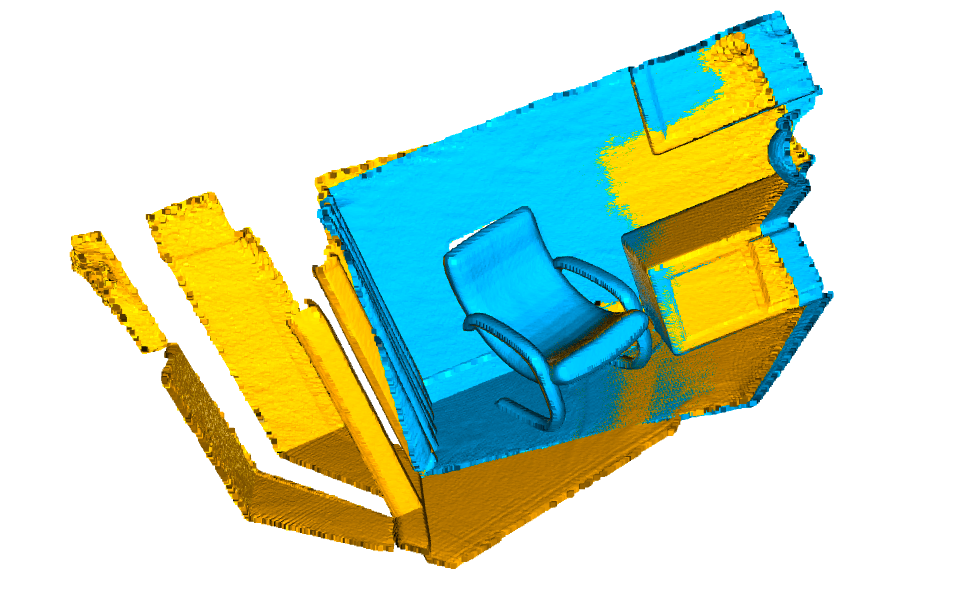
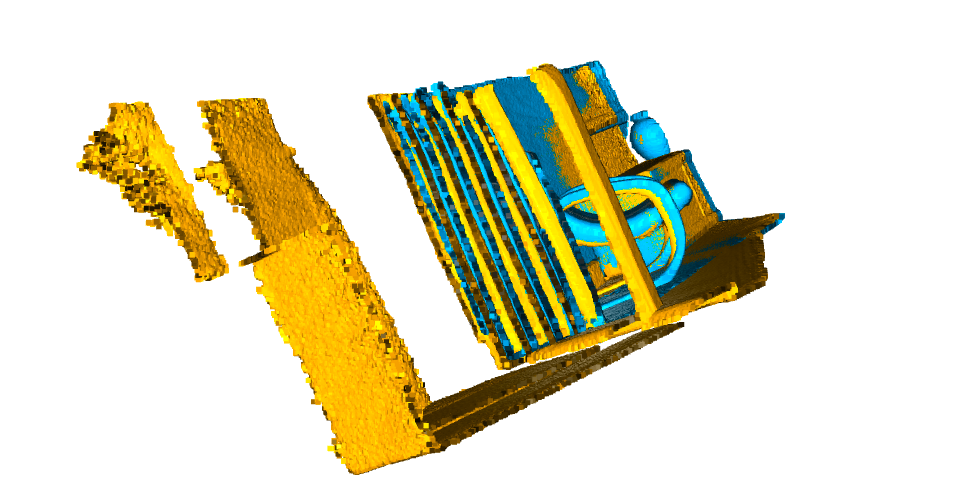
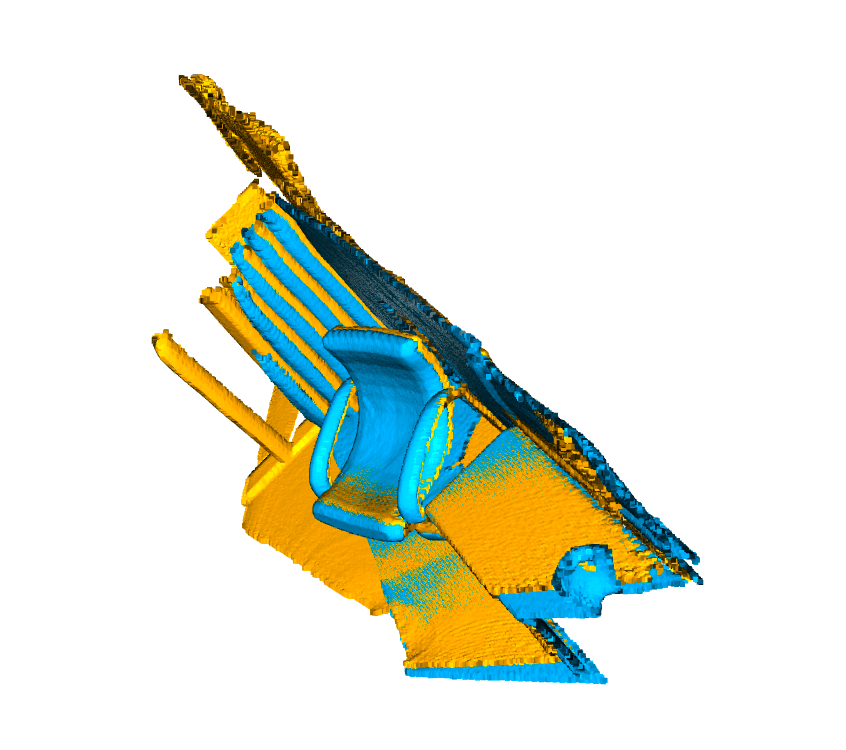
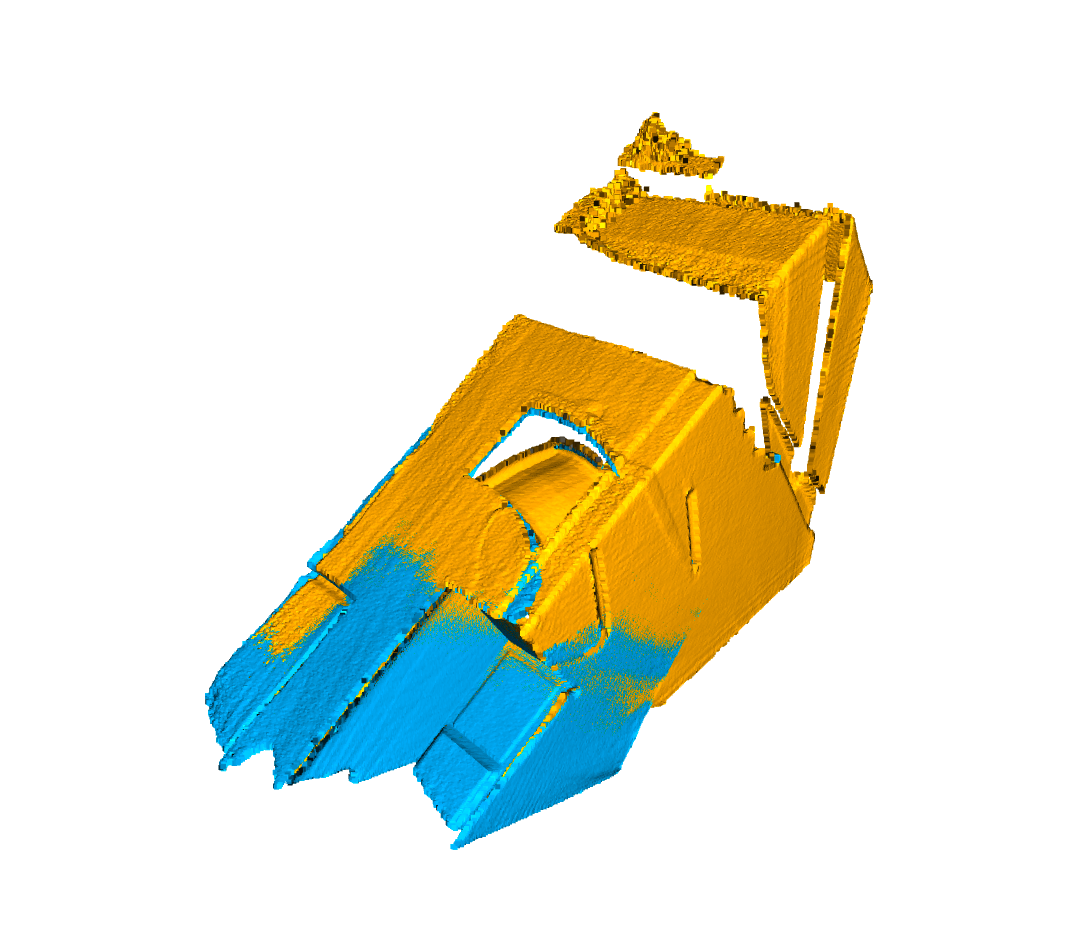

We use the same workflow as above, but apply it to the car point clouds `car1` and `car2`.

In [4]:
# 2. Perform global registration on car1.ply and car2.ply using RANSAC based on FPFH features.
source_car = o3d.io.read_point_cloud(str(DATA_DIR / "global_registration/car1.ply"))
target_car = o3d.io.read_point_cloud(str(DATA_DIR / "global_registration/car2.ply"))

voxel_size = 0.05

# Downsample the point clouds
source_down_car = source_car.voxel_down_sample(voxel_size)
target_down_car = target_car.voxel_down_sample(voxel_size)

# FPFH feature extraction
radius_normal = voxel_size * 2
radius_feature = voxel_size * 5

source_down_car.estimate_normals(
    o3d.geometry.KDTreeSearchParamHybrid(radius=radius_normal, max_nn=30))
target_down_car.estimate_normals(
    o3d.geometry.KDTreeSearchParamHybrid(radius=radius_normal, max_nn=30))

source_fpfh_car = o3d.pipelines.registration.compute_fpfh_feature(
    source_down_car,
    o3d.geometry.KDTreeSearchParamHybrid(radius=radius_feature, max_nn=100))
target_fpfh_car = o3d.pipelines.registration.compute_fpfh_feature(
    target_down_car,
    o3d.geometry.KDTreeSearchParamHybrid(radius=radius_feature, max_nn=100))

# RANSAC-based global registration
distance_threshold = voxel_size * 1.5
point_to_point = o3d.pipelines.registration.TransformationEstimationPointToPoint(False)

o3d.utility.random.seed(0) # Fixed seed for reproducibility
ransac_result_car = o3d.pipelines.registration.registration_ransac_based_on_feature_matching(
    source_down_car, target_down_car,
    source_fpfh_car, target_fpfh_car,
    True,
    distance_threshold,
    point_to_point)

print(ransac_result_car)
print("Transformation is:")
print(ransac_result_car.transformation)

draw_registrations(source_car, target_car, ransac_result_car.transformation, recolor = True)

RegistrationResult with fitness=9.974212e-01, inlier_rmse=2.332888e-02, and correspondence_set size of 3481
Access transformation to get result.
Transformation is:
[[-0.02202777  0.01373819  0.99966296  2.01281788]
 [ 0.9997204  -0.00829533  0.02214304  2.07169409]
 [ 0.00859674  0.99987122 -0.01355162  0.00570737]
 [ 0.          0.          0.          1.        ]]


#### Results

Below you can see the screenshots from the global registration of `car1` and `car2`. The fitness is considerably higher than for the room scans (0.992 compared with 0.671). This indicates that the two car clouds overlap almost completely, i.e. `car2.ply` is essentially the same scan of the car as `car1.ply` placed in a different pose, whereas `r1` and `r2` only partially overlap. The visualisation confirms that the alignment is correct: the body panels, wheel arches and windscreen coincide, and the car is not reversed front-to-back. A slight offset between the two ground planes is still visible from the side, showing that this result, like the room registration, is a coarse alignment.

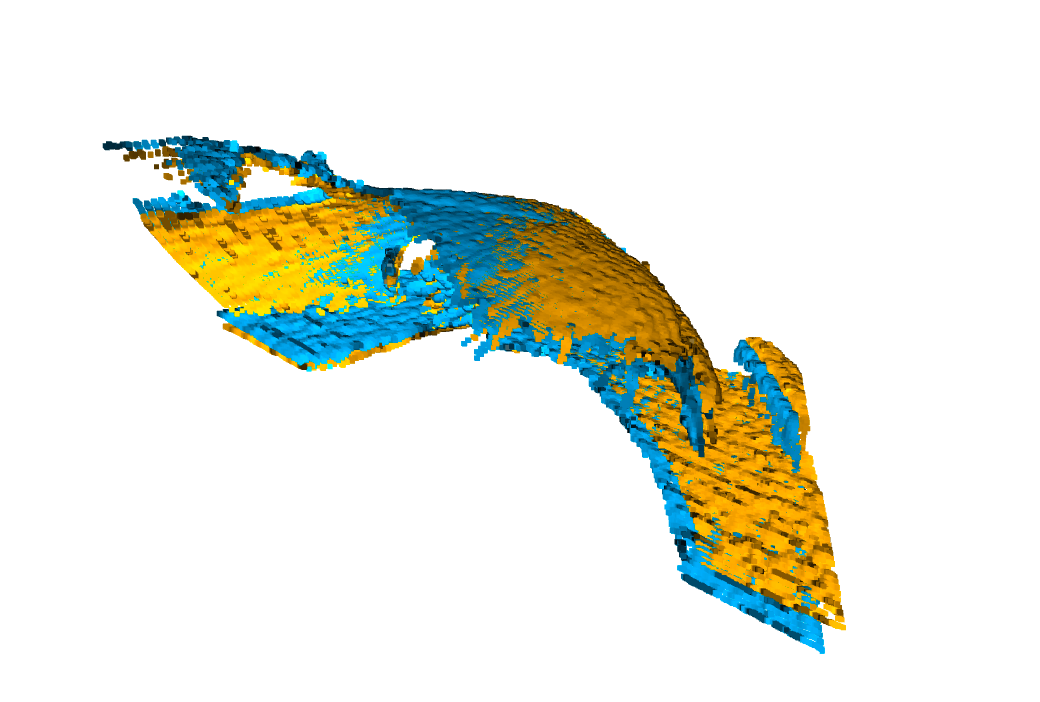
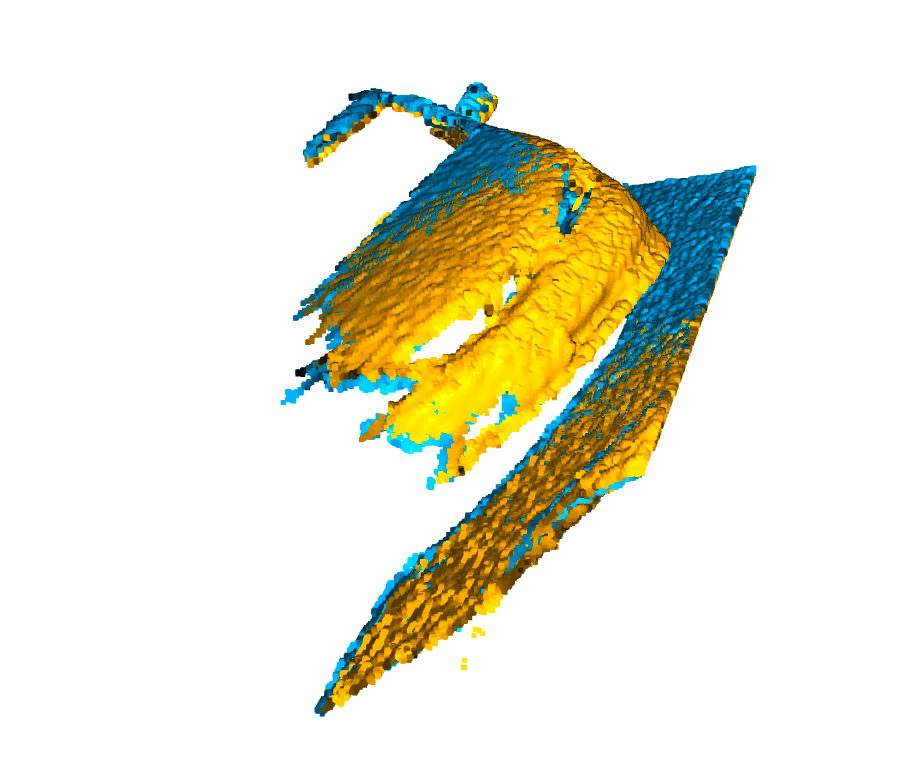
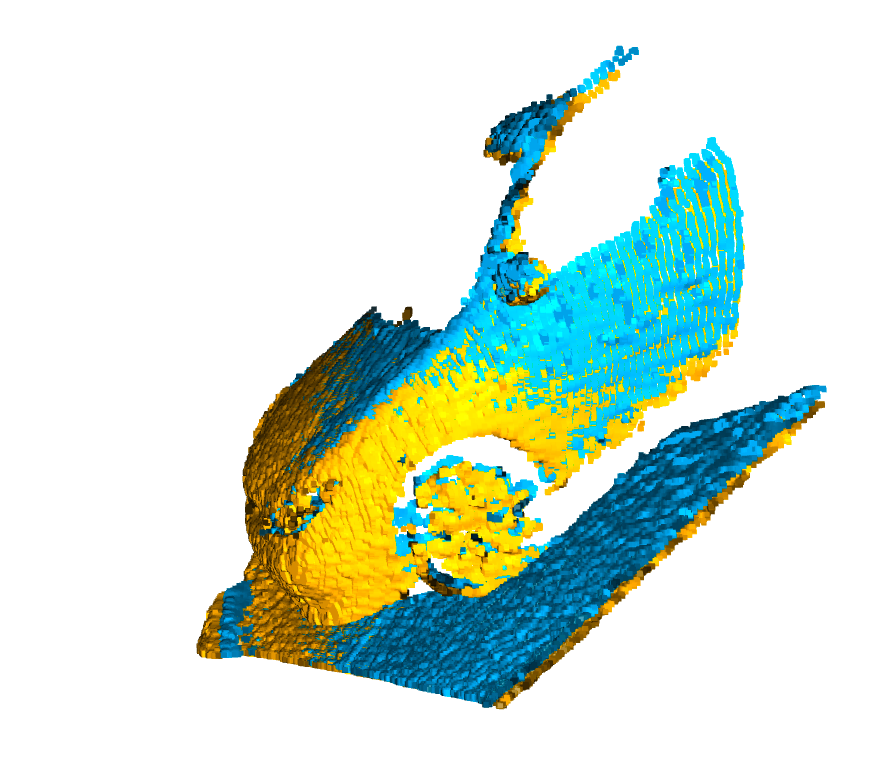
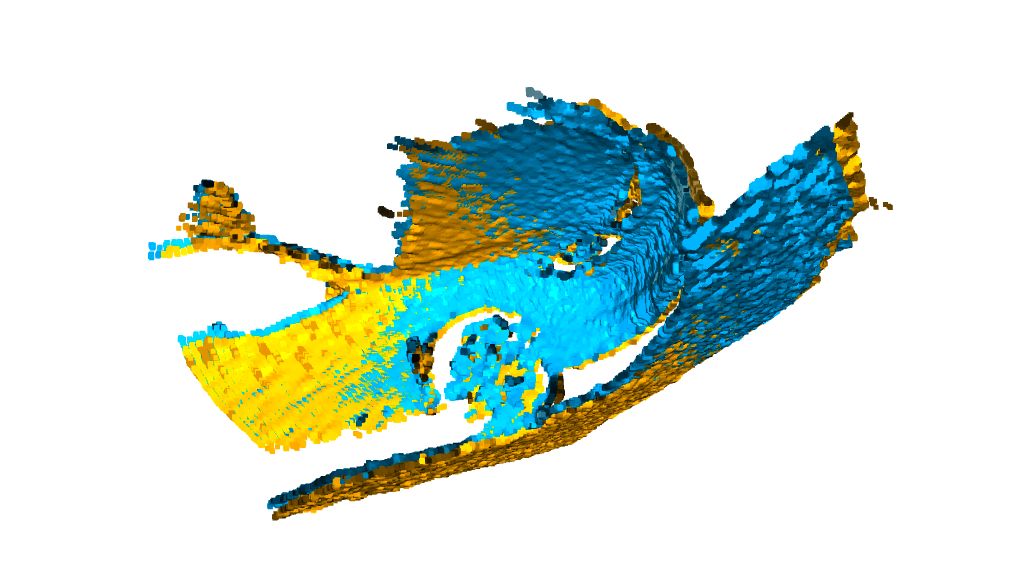

### Task 2 (Challenge)

The approach follows the same pipeline as Exercise 2 from Monday. First, the ICP correspondence threshold is defined, and surface normals are estimated for `r1` and `r2`, as these are required for point-to-plane ICP. The transformation obtained with RANSAC in Task 1 is then evaluated at this threshold, which provides a reference for the subsequent refinement. ICP is initialised with the RANSAC transformation and run with both the point-to-point and the point-to-plane error metrics. As the two methods yield nearly identical results, only the point-to-plane registration is visualised.

In [5]:
# Local registration of r1 and r2 using ICP
threshold = voxel_size * 0.4

source.estimate_normals(
    o3d.geometry.KDTreeSearchParamHybrid(radius=radius_normal, max_nn=30))
target.estimate_normals(
    o3d.geometry.KDTreeSearchParamHybrid(radius=radius_normal, max_nn=30))

# RANSAC result evaluated at the ICP threshold
evaluation = o3d.pipelines.registration.evaluate_registration(
    source, target, threshold, ransac_result.transformation)
print("Before ICP (RANSAC):")
print(evaluation)

point_to_point = o3d.pipelines.registration.TransformationEstimationPointToPoint()
point_to_plane = o3d.pipelines.registration.TransformationEstimationPointToPlane()

icp_p2p = o3d.pipelines.registration.registration_icp(
    source, target, threshold, ransac_result.transformation, point_to_point)
icp_p2l = o3d.pipelines.registration.registration_icp(
    source, target, threshold, ransac_result.transformation, point_to_plane)

print("Point-to-point ICP:")
print(icp_p2p)
print("Point-to-plane ICP:")
print(icp_p2l)

draw_registrations(source, target, icp_p2l.transformation, recolor = True)

Before ICP (RANSAC):
RegistrationResult with fitness=3.398044e-01, inlier_rmse=1.132384e-02, and correspondence_set size of 67565
Access transformation to get result.
Point-to-point ICP:
RegistrationResult with fitness=6.082531e-01, inlier_rmse=8.372367e-03, and correspondence_set size of 120942
Access transformation to get result.
Point-to-plane ICP:
RegistrationResult with fitness=6.210677e-01, inlier_rmse=6.564716e-03, and correspondence_set size of 123490
Access transformation to get result.


#### Results

Below you can see the screenshots from the local registration of `r1` and `r2`. ICP refinement clearly improves the alignment of `r1` and `r2`. When evaluated at the 2 cm threshold, the RANSAC transformation reaches a fitness of only 0.471, compared with 0.671 at the 7.5 cm threshold used in Task 1. This confirms that the global registration provides only a coarse alignment. The visualisation confirms the improvement: on the shared surfaces, such as the chair, the desk, the floor and the walls, the yellow and blue points are now finely interleaved, and the doubled chair armrests observed after RANSAC are no longer visible.

Point-to-point and point-to-plane ICP converge to practically identical results (fitness 0.6212 compared with 0.6211, and equal RMSE to within 0.1 $\mu m$). Since the initial alignment provided by RANSAC is already close to the solution, both error metrics converge to the same minimum.

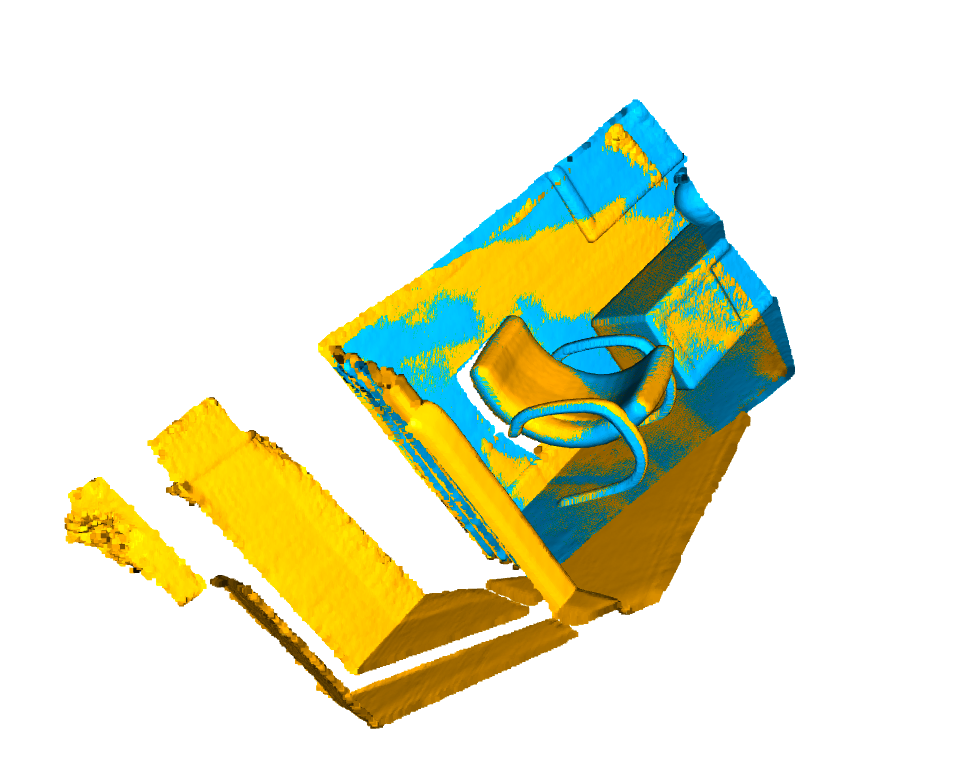
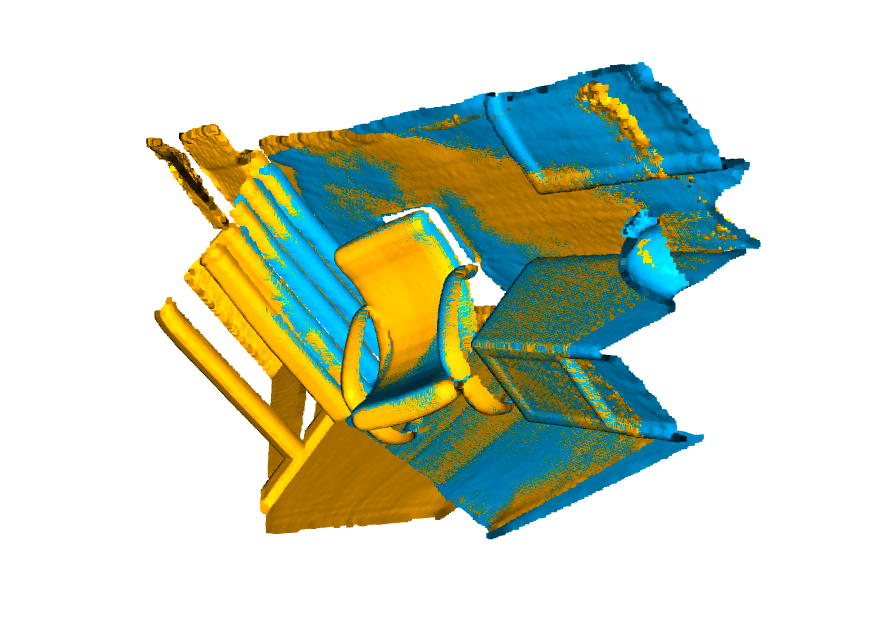
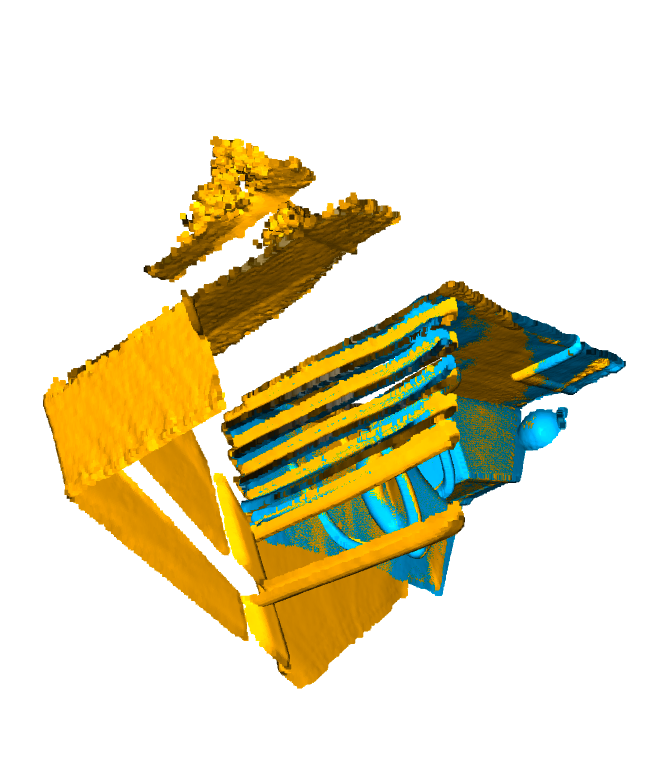
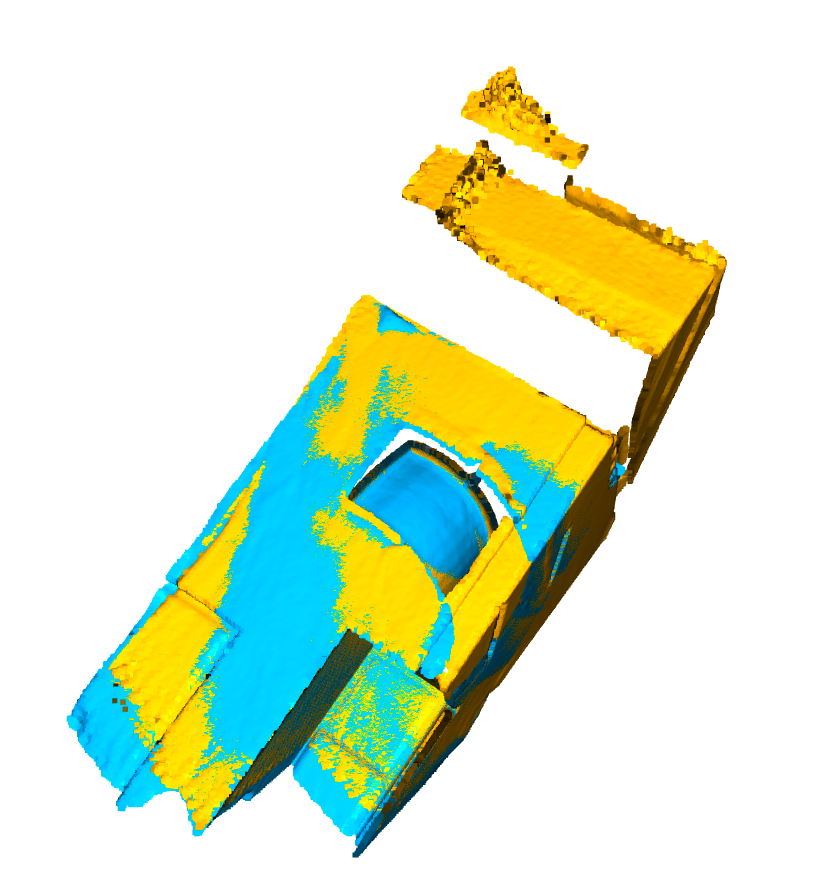

For `car1` and `car2`, we follow the same procedure as for `r1` and `r2`.

In [6]:
# Local registration of car1 and car2 using ICP
source_car.estimate_normals(
    o3d.geometry.KDTreeSearchParamHybrid(radius=radius_normal, max_nn=30))
target_car.estimate_normals(
    o3d.geometry.KDTreeSearchParamHybrid(radius=radius_normal, max_nn=30))

evaluation_car = o3d.pipelines.registration.evaluate_registration(
    source_car, target_car, threshold, ransac_result_car.transformation)
print("Before ICP (RANSAC):")
print(evaluation_car)

icp_p2p_car = o3d.pipelines.registration.registration_icp(
    source_car, target_car, threshold, ransac_result_car.transformation, point_to_point)
icp_p2l_car = o3d.pipelines.registration.registration_icp(
    source_car, target_car, threshold, ransac_result_car.transformation, point_to_plane)

print("Point-to-point ICP:")
print(icp_p2p_car)
print("Point-to-plane ICP:")
print(icp_p2l_car)

draw_registrations(source_car, target_car, icp_p2l_car.transformation, recolor = True)

Before ICP (RANSAC):
RegistrationResult with fitness=9.476290e-01, inlier_rmse=8.906258e-03, and correspondence_set size of 157513
Access transformation to get result.
Point-to-point ICP:
RegistrationResult with fitness=9.819454e-01, inlier_rmse=7.173010e-03, and correspondence_set size of 163217
Access transformation to get result.
Point-to-plane ICP:
RegistrationResult with fitness=9.876367e-01, inlier_rmse=5.442070e-03, and correspondence_set size of 164163
Access transformation to get result.


#### Results

ICP refinement substantially improves the alignment of `car1` and `car2`. When evaluated at the 2 cm threshold, the RANSAC transformation reaches a fitness of only 0.545, compared with 0.992 at the 7.5 cm threshold used in Task 1. The fitness close to 1 confirms that the two clouds overlap almost completely, so that, in contrast to the room scans, the fitness is limited by registration accuracy rather than by missing overlap. The visualisation confirms the improvement. The yellow and blue points are finely interleaved over the car body, the wheels and the ground plane, and the offset between the two ground planes observed after RANSAC is no longer visible.

Point-to-plane ICP reaches a lower RMSE than point-to-point ICP and a slightly higher fitness. A plausible explanation is that the car body consists largely of smooth, curved surfaces. The point-to-plane metric only penalises the distance along the surface normal, which allows points to slide along the surface instead of being pulled towards specific target points whose positions depend on the sampling. Point-to-plane ICP is therefore the more suitable choice for this pair.

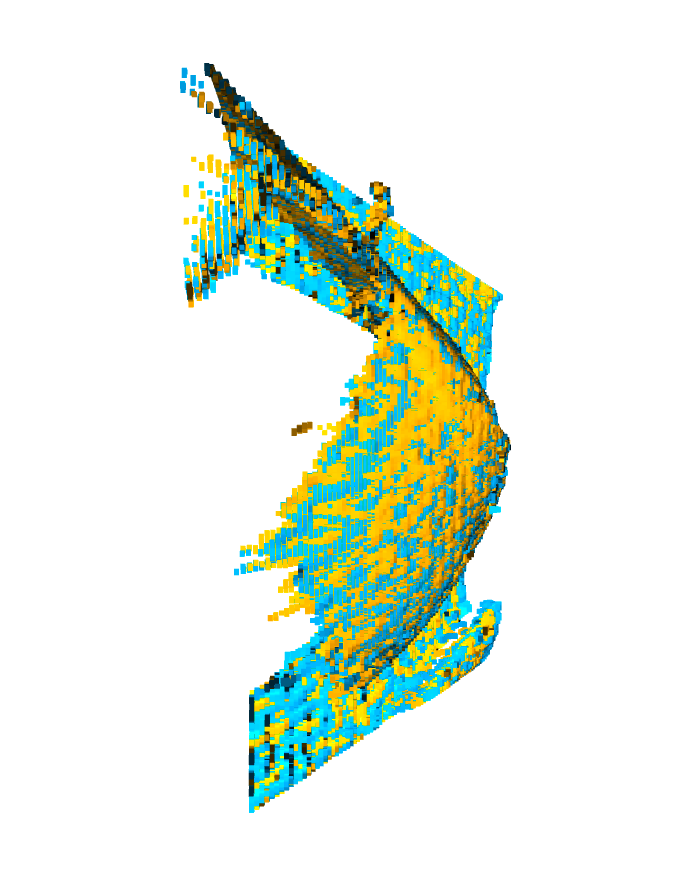
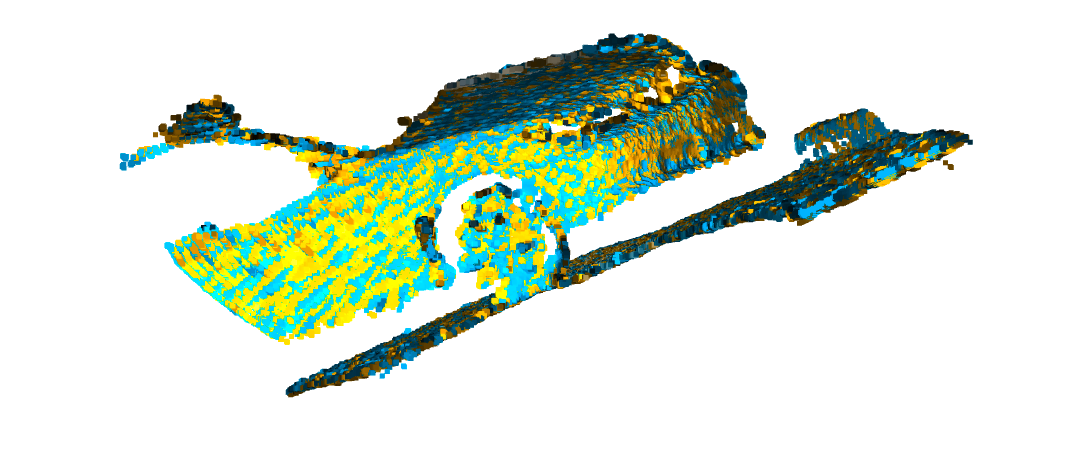
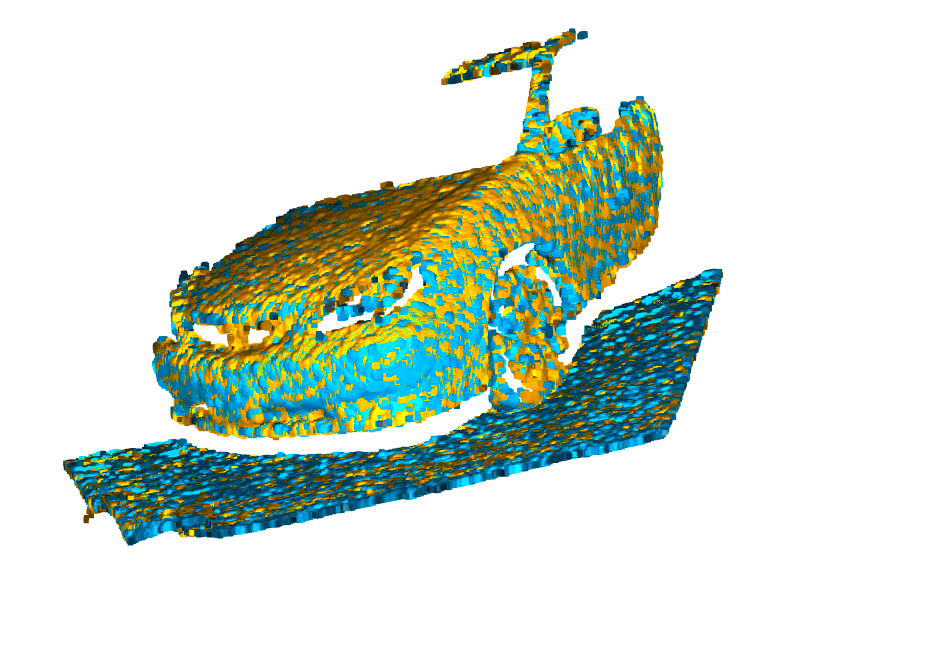
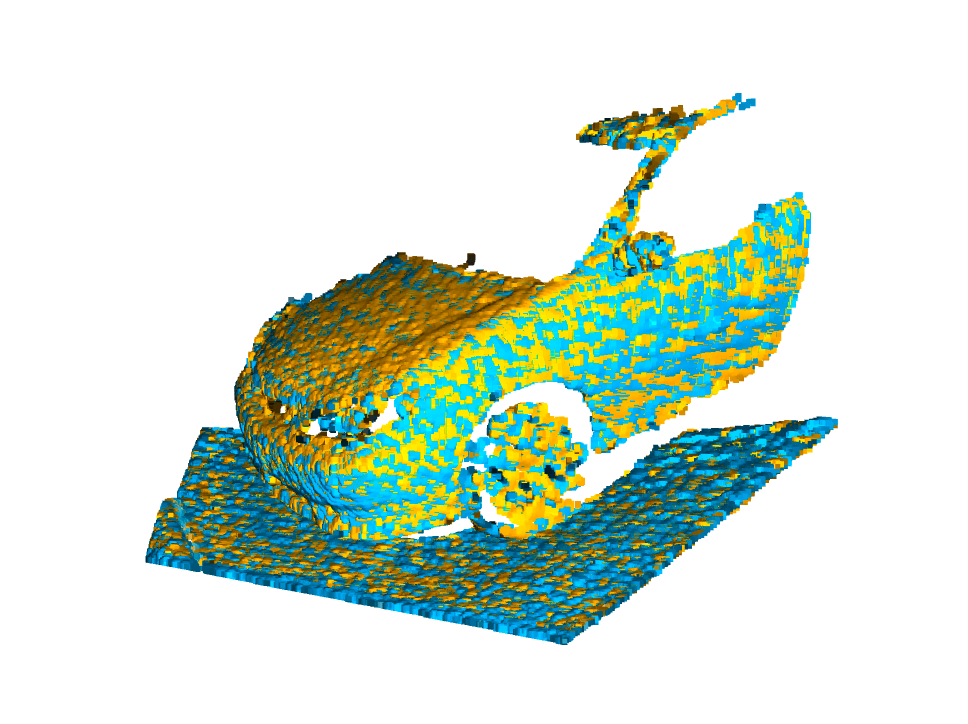

#### Car reconstruction

The second part of the challenge is to reconstruct the car from the RGB-D images in the `data/car_challange` folder. Since the intrinsic parameters of the camera are not provided, the default PrimeSense intrinsics from Open3D are used, which match the 640 × 480 resolution of the images. Each colour image is combined with the corresponding depth image to form an RGB-D image, which is then converted into a point cloud. The point cloud is flipped, as it would otherwise be upside down, and downsampled to 2 cm voxels. Its normals are then estimated, as these are required for point-to-plane ICP.

The first frame initialises the merged point cloud, and afterwards only every fifth frame is used to reduce the computation time. Each new frame is registered to the merged point cloud with point-to-plane ICP, using a correspondence threshold of 5 cm. Since the camera moves only slightly between the selected frames, ICP is initialised with the transformation of the previous frame. The new frame is then transformed into the coordinate system of the merged point cloud and added to it, after which the merged point cloud is downsampled again to keep the number of points bounded. The fitness and the size of the merged point cloud are printed every 100 frames.

In [7]:
# 2b: 3D reconstruction from RGB-D images
camera = o3d.camera.PinholeCameraIntrinsic(
    o3d.camera.PinholeCameraIntrinsicParameters.PrimeSenseDefault)

voxel_size_rec = 0.02
threshold_rec = 0.05
frame_step = 5
n_frames = 1722

color_raw = o3d.io.read_image(str(DATA_DIR / "car_challange/rgb/0000001.jpg"))
depth_raw = o3d.io.read_image(str(DATA_DIR / "car_challange/depth/0000001.png"))
rgbd_image = o3d.geometry.RGBDImage.create_from_color_and_depth(
    color_raw, depth_raw, convert_rgb_to_intensity = False)

merged = o3d.geometry.PointCloud.create_from_rgbd_image(rgbd_image, camera)
merged.transform([[1, 0, 0, 0], [0, -1, 0, 0], [0, 0, -1, 0], [0, 0, 0, 1]])
merged = merged.voxel_down_sample(voxel_size_rec)
merged.estimate_normals(
    o3d.geometry.KDTreeSearchParamHybrid(radius=voxel_size_rec * 2, max_nn=30))

prev_transform = np.identity(4)

for idx in range(1 + frame_step, n_frames + 1, frame_step):
    color_raw = o3d.io.read_image(str(DATA_DIR / f"car_challange/rgb/{idx:07d}.jpg"))
    depth_raw = o3d.io.read_image(str(DATA_DIR / f"car_challange/depth/{idx:07d}.png"))
    rgbd_image = o3d.geometry.RGBDImage.create_from_color_and_depth(
        color_raw, depth_raw, convert_rgb_to_intensity = False)

    new_pcd = o3d.geometry.PointCloud.create_from_rgbd_image(rgbd_image, camera)
    new_pcd.transform([[1, 0, 0, 0], [0, -1, 0, 0], [0, 0, -1, 0], [0, 0, 0, 1]])
    new_pcd = new_pcd.voxel_down_sample(voxel_size_rec)
    new_pcd.estimate_normals(
        o3d.geometry.KDTreeSearchParamHybrid(radius=voxel_size_rec * 2, max_nn=30))

    # Use the previous pose as the initial guess, since the camera moves little between frames
    icp_res = o3d.pipelines.registration.registration_icp(
        new_pcd, merged, threshold_rec, prev_transform, point_to_plane)

    new_pcd.transform(icp_res.transformation)
    merged += new_pcd
    merged = merged.voxel_down_sample(voxel_size_rec)
    prev_transform = icp_res.transformation

    if idx % 100 == 1:
        print(f"frame {idx:>4}: fitness={icp_res.fitness:.3f}  points in map={len(merged.points)}")

o3d.visualization.draw_geometries([merged])

frame  101: fitness=0.995  points in map=29873
frame  201: fitness=0.992  points in map=36307
frame  301: fitness=0.997  points in map=43143
frame  401: fitness=1.000  points in map=62485
frame  501: fitness=0.999  points in map=71608
frame  601: fitness=0.996  points in map=77441
frame  701: fitness=0.987  points in map=94024
frame  801: fitness=0.985  points in map=100524
frame  901: fitness=0.999  points in map=122710
frame 1001: fitness=0.959  points in map=136200
frame 1101: fitness=0.955  points in map=124792
frame 1201: fitness=0.990  points in map=111702
frame 1301: fitness=1.000  points in map=114675
frame 1401: fitness=0.947  points in map=124088
frame 1501: fitness=1.000  points in map=132269
frame 1601: fitness=0.982  points in map=142867
frame 1701: fitness=0.982  points in map=159640


##### Results

All 345 selected frames are registered, and the car is recognisable from all sides. For most frames the fitness is between 0.95 and 1.00, meaning that nearly all points of the new frame have a correspondence in the merged point cloud within 5 cm. However, since each frame is aligned to a point cloud built from the previous estimates, small registration errors accumulate over the sequence (drift). This is visible in the reconstruction, where the ground below the car is split into several slightly tilted layers instead of a single plane, and in the fitness, which drops towards the end of the sequence.

The reconstruction could be improved in several ways. The drift could be reduced with pose graph optimisation, as in Open3D's multiway registration, where frames that see the same part of the car are also registered to each other (loop closure), and the accumulated error is distributed over all poses. Instead of merging and repeatedly downsampling the point clouds, the frames could be fused in a TSDF volume, which averages the depth measurements and produces a cleaner surface that can also be converted into a mesh. Finally, the actual intrinsics of the camera should be used instead of the PrimeSense defaults if they are available.

## Declaration of AI Usage

- We used AI to help us a bit with the second challenge.
- We used AI to help us refine the code documentation.